# پروژه پایانی درس احتمال ۱
## مدل‌سازی و شبیه‌سازی توزیع نمایی: فاصله زمانی بین دو بار چک کردن گوشی موبایل

**درس:** احتمال ۱ &nbsp;|&nbsp; **مدرس:** استاد رامین کاظمی &nbsp;|&nbsp; **مسئول پروژه:** پارسا ستایش

---

### معرفی پدیده
پدیده تصادفی انتخاب‌شده برای این پروژه، **فاصله زمانی بین دو بار متوالی چک کردن گوشی موبایل** توسط یک کاربر معمولی است. این متغیر تصادفی را با نماد $X$ (بر حسب دقیقه) نشان می‌دهیم.

فرض اصلی پروژه این است که این متغیر از توزیع نمایی پیروی می‌کند:

$$X \sim \text{Exponential}(\lambda)$$

در ادامه، طبق ۵ گام تعریف‌شده در صورت پروژه، به‌صورت کامل این پدیده را مدل‌سازی، تحلیل و شبیه‌سازی می‌کنیم.

In [ ]:
# ============================================================
# Imports and global settings
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.integrate import quad

np.random.seed(42)
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print("Libraries loaded successfully.")

Libraries loaded successfully.


---
## گام اول: انتخاب پدیده و توجیه مدل‌سازی (The "Why")

### پدیده مورد مطالعه
فاصله زمانی بین دو بار متوالی برداشتن و روشن‌کردن صفحه گوشی موبایل توسط یک کاربر، یک متغیر تصادفی **پیوسته و نامنفی** است که آن را با $X$ نشان می‌دهیم.

### توجیه ریاضی انتخاب توزیع نمایی
برای این‌که بتوان $X$ را با توزیع نمایی مدل کرد، باید فرض شود که فرآیند «چک‌کردن گوشی» یک **فرآیند پواسون** با نرخ ثابت $\lambda$ (تعداد دفعات چک‌کردن در واحد زمان) است. سه شرط لازم برای این فرض عبارت‌اند از:

1. **استقلال رخدادها:** تصمیم کاربر برای نگاه‌کردن به گوشی در یک لحظه، به رخدادهای گذشته وابسته نیست (فرضی معقول در نبود محرک بیرونی خاص مانند نوتیفیکیشن).
2. **نرخ ثابت (Homogeneity):** به‌طور میانگین، در بازه‌های زمانی با طول یکسان، نرخ وقوع رخداد ثابت است.
3. **عدم هم‌زمانی رخدادها (Orderliness):** احتمال وقوع دو رخداد (دو بار چک‌کردن) در یک بازه زمانی بسیار کوچک $\Delta t$ به سمت صفر میل می‌کند:

$$P(\text{دو رخداد در } \Delta t) \longrightarrow 0 \quad \text{as} \quad \Delta t \to 0$$

با برقراری این سه شرط، تعداد دفعات چک‌کردن گوشی در بازه زمانی $[0,t]$ از توزیع پواسون پیروی می‌کند:

$$N(t) \sim \text{Poisson}(\lambda t)$$

### اتصال پواسون به نمایی
فاصله زمانی بین دو رخداد متوالی (inter-arrival time) در یک فرآیند پواسون، دقیقاً از توزیع نمایی پیروی می‌کند. اثبات کوتاه:

$$P(X > t) = P(N(t) = 0) = e^{-\lambda t}$$

پس تابع توزیع تجمعی (CDF) برابر است با:

$$F(t) = P(X \le t) = 1 - e^{-\lambda t}, \quad t \ge 0$$

و با مشتق‌گیری، تابع چگالی احتمال (PDF) به‌دست می‌آید:

$$f(x) = \lambda e^{-\lambda x}, \quad x \ge 0$$

### چرا این پدیده منطقی است؟
- بین دو بار چک‌کردن گوشی معمولاً هیچ «حافظه‌ای» از فاصله قبلی وجود ندارد؛ یعنی این‌که کاربر ۵ دقیقه پیش گوشی را چک کرده یا نکرده، تاثیر مستقیمی روی احتمال چک‌کردن در دقیقه بعد ندارد.
- در بازه‌های زمانی بسیار کوتاه (مثلاً یک ثانیه)، احتمال این‌که دقیقاً در همان لحظه دو بار چک‌کردن رخ دهد عملاً صفر است.

بر همین اساس، فرض $X \sim \text{Exponential}(\lambda)$ برای مدل‌سازی این پدیده توجیه تحلیلی دارد.

---
## گام دوم: تحلیل وضعیت فعلی سیستم (The "Present")

فرض می‌کنیم بر اساس داده‌های مشاهده‌شده (یا آمار میانگین رفتار کاربران)، به‌طور متوسط هر **۱۲ دقیقه** یک‌بار گوشی چک می‌شود. بنابراین نرخ $\lambda$ برابر است با:

$$\lambda = \frac{1}{\text{میانگین فاصله زمانی}} = \frac{1}{12} \; \text{(per minute)}$$

### امید ریاضی و واریانس
برای $X \sim \text{Exponential}(\lambda)$ داریم:

$$E[X] = \frac{1}{\lambda}, \qquad \text{Var}(X) = \frac{1}{\lambda^2}$$

**دلالت مفهومی:** $E[X]$ همان میانگین فاصله زمانی بین دو بار چک‌کردن است (۸ دقیقه) و $\text{Var}(X)$ نشان‌دهنده میزان پراکندگی این فاصله‌ها حول میانگین است؛ هرچه واریانس بیشتر باشد، رفتار کاربر نامنظم‌تر است.

### آستانه بحرانی
یک آستانه بحرانی $c$ تعریف می‌کنیم؛ مثلاً $c = 20$ دقیقه، به‌معنای «یک دوره تمرکز طولانی بدون نگاه‌کردن به گوشی». می‌خواهیم احتمال $P(X > c)$ را محاسبه کنیم:

$$P(X > c) = e^{-\lambda c}$$

In [ ]:
# ============================================================
# Step 2: Theoretical mean, variance, and threshold probability
# ============================================================
lam = 1 / 12         # rate parameter (events per minute)
c_threshold = 20      # critical threshold in minutes

# Using scipy.stats.expon (scale = 1/lambda)
rv = stats.expon(scale=1 / lam)

E_X_theory   = rv.mean()
Var_X_theory = rv.var()
P_exceed_theory = rv.sf(c_threshold)   # sf = 1 - cdf = P(X > c)

print(f"Rate parameter lambda           : {lam:.4f} events/minute")
print(f"Theoretical E[X]                : {E_X_theory:.4f} minutes")
print(f"Theoretical Var(X)              : {Var_X_theory:.4f} minutes^2")
print(f"Critical threshold c            : {c_threshold} minutes")
print(f"Theoretical P(X > c)            : {P_exceed_theory:.4f}")

Rate parameter lambda           : 0.0833 events/minute
Theoretical E[X]                : 12.0000 minutes
Theoretical Var(X)              : 144.0000 minutes^2
Critical threshold c            : 20 minutes
Theoretical P(X > c)            : 0.1889


---
## گام سوم: پیش‌بینی آینده و تحلیل سناریوهای شرطی (The "Future")

### سناریوی شرطی
سناریو: فرض کنید کاربر تا کنون به مدت $s = 10$ دقیقه گوشی خود را چک نکرده است. می‌خواهیم بدانیم احتمال این‌که او **حداقل** $t = 10$ دقیقه دیگر هم گوشی را چک نکند چقدر است؛ یعنی محاسبه:

$$P(X > s+t \mid X > s)$$

### خاصیت بی‌حافظگی (Memorylessness)
توزیع نمایی (مانند توزیع هندسی در حالت گسسته) دارای خاصیت بی‌حافظگی است:

$$P(X > s+t \mid X > s) = P(X > t)$$

**اثبات:**

$$P(X > s+t \mid X > s) = \frac{P(X > s+t)}{P(X > s)} = \frac{e^{-\lambda (s+t)}}{e^{-\lambda s}} = e^{-\lambda t} = P(X > t)$$

**تفسیر مفهومی در سیستم ما:** این خاصیت به این معناست که مدت‌زمانی که از آخرین چک‌کردن گوشی گذشته، هیچ اطلاعاتی درباره‌ی این‌که چقدر دیگر طول می‌کشد تا کاربر دوباره گوشی را چک کند، به ما نمی‌دهد. به بیان دیگر، گوشی «حافظه» ندارد و در هر لحظه، احتمال چک‌شدن آن در بازه بعدی مستقل از گذشته است. این ویژگی همان فرض بنیادی فرآیند پواسون در گام اول را دوباره تایید می‌کند.

### قانون لوتوس (LOTUS)
یک تابع غیرخطی از $X$ تعریف می‌کنیم که نشان‌دهنده «ارزش تمرکز مفید» کاربر باشد. فرض می‌کنیم بازه‌های چک‌کردن طولانی‌تر مفیدند، اما بعد از ۱۵ دقیقه سود اضافه‌ای ندارند (اشباع می‌شود):

$$g(X) = \min(X, 15)$$

طبق قانون لوتوس (بدون نیاز به یافتن توزیع $g(X)$):

$$E[g(X)] = \int_0^{\infty} g(x)\, f(x)\, dx = \int_0^{15} x\,\lambda e^{-\lambda x}\,dx \;+\; 15 \cdot P(X > 15)$$

In [ ]:
# ============================================================
# Step 3: Conditional probability, memorylessness, and LOTUS
# ============================================================
s, t = 10, 10  # minutes

P_cond   = stats.expon(scale=1/lam).sf(s+t) / stats.expon(scale=1/lam).sf(s)
P_direct = stats.expon(scale=1/lam).sf(t)

print("---- Memorylessness check ----")
print(f"P(X > s+t | X > s) = {P_cond:.4f}")
print(f"P(X > t)            = {P_direct:.4f}")
print(f"Equal? {np.isclose(P_cond, P_direct)}")

print("\n---- LOTUS: E[g(X)] for g(X) = min(X, 15) ----")

def g(x, cap=15):
    return np.minimum(x, cap)

# Analytical value via numerical integration of x * f(x) on [0, cap] plus the tail term
cap = 15
integrand = lambda x: x * lam * np.exp(-lam * x)
partial_integral, _ = quad(integrand, 0, cap)
tail_term = cap * stats.expon(scale=1/lam).sf(cap)
E_gX_theory = partial_integral + tail_term

print(f"E[g(X)] (theoretical, via LOTUS) = {E_gX_theory:.4f} minutes")

---- Memorylessness check ----
P(X > s+t | X > s) = 0.4346
P(X > t)            = 0.4346
Equal? True

---- LOTUS: E[g(X)] for g(X) = min(X, 15) ----
E[g(X)] (theoretical, via LOTUS) = 8.5619 minutes


---
## گام چهارم: شبیه‌سازی مونت‌کارلو و اعتبارسنجی (The "Reality Check")

در این گام، سیستم را **۲۰۰٬۰۰۰ بار** شبیه‌سازی می‌کنیم (بیشتر از حداقل ۱۰۰٬۰۰۰ بار خواسته‌شده) تا اثر قانون اعداد بزرگ (LLN) به‌وضوح دیده شود. سپس هیستوگرام داده‌های شبیه‌سازی‌شده را با نمودار تئوری PDF مقایسه می‌کنیم و میانگین و واریانس تجربی را با مقادیر تحلیلی گام دوم مقایسه می‌کنیم.

In [ ]:
# ============================================================
# Step 4a: Monte Carlo simulation
# ============================================================
N_SIM = 200_000

samples = np.random.exponential(scale=1/lam, size=N_SIM)

E_X_sim   = samples.mean()
Var_X_sim = samples.var()
P_exceed_sim = np.mean(samples > c_threshold)

print(f"Number of simulations           : {N_SIM:,}")
print(f"Simulated mean  E[X]            : {E_X_sim:.4f} minutes")
print(f"Simulated variance Var(X)       : {Var_X_sim:.4f} minutes^2")
print(f"Simulated P(X > {c_threshold})            : {P_exceed_sim:.4f}")

Number of simulations           : 200,000
Simulated mean  E[X]            : 12.0034 minutes
Simulated variance Var(X)       : 143.5591 minutes^2
Simulated P(X > 20)            : 0.1893


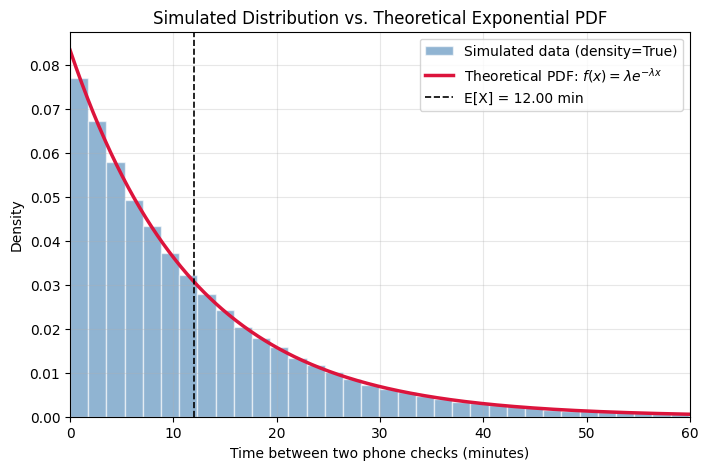

In [ ]:
# ============================================================
# Step 4b: Histogram vs theoretical PDF
# ============================================================
x_range = np.linspace(0, samples.max(), 1000)
pdf_theory = stats.expon(scale=1/lam).pdf(x_range)

plt.figure()
plt.hist(samples, bins=80, density=True, alpha=0.6,
         color="steelblue", edgecolor="white", label="Simulated data (density=True)")
plt.plot(x_range, pdf_theory, color="crimson", linewidth=2.5,
         label=r"Theoretical PDF: $f(x)=\lambda e^{-\lambda x}$")
plt.axvline(E_X_theory, color="black", linestyle="--", linewidth=1.2,
            label=f"E[X] = {E_X_theory:.2f} min")
plt.title("Simulated Distribution vs. Theoretical Exponential PDF")
plt.xlabel("Time between two phone checks (minutes)")
plt.ylabel("Density")
plt.legend()
plt.xlim(0, 60)
plt.show()

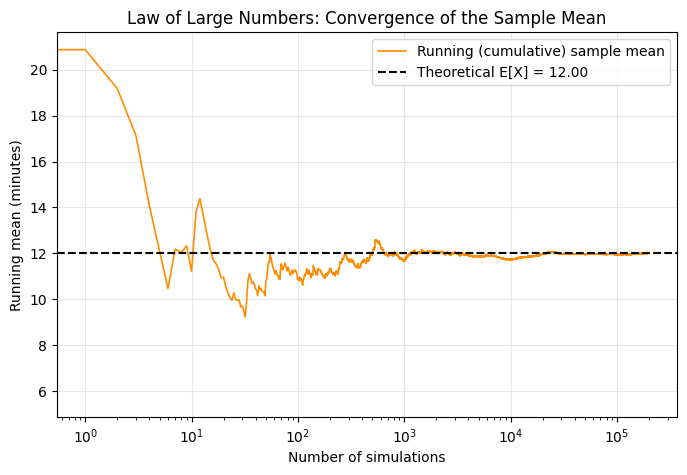

In [ ]:
# ============================================================
# Step 4c: Law of Large Numbers - convergence of the running mean
# ============================================================
running_mean = np.cumsum(samples) / np.arange(1, N_SIM + 1)

plt.figure()
plt.plot(running_mean, color="darkorange", linewidth=1.2, label="Running (cumulative) sample mean")
plt.axhline(E_X_theory, color="black", linestyle="--", linewidth=1.5,
            label=f"Theoretical E[X] = {E_X_theory:.2f}")
plt.title("Law of Large Numbers: Convergence of the Sample Mean")
plt.xlabel("Number of simulations")
plt.ylabel("Running mean (minutes)")
plt.xscale("log")
plt.legend()
plt.show()

In [ ]:
# ============================================================
# Step 4d: Verifying LOTUS result via simulation
# ============================================================
g_samples = g(samples, cap=15)
E_gX_sim = g_samples.mean()

print(f"Theoretical E[g(X)] (LOTUS) = {E_gX_theory:.4f}")
print(f"Simulated   E[g(X)]        = {E_gX_sim:.4f}")
print(f"Relative error              = {abs(E_gX_sim - E_gX_theory) / E_gX_theory * 100:.3f}%")

Theoretical E[g(X)] (LOTUS) = 8.5619
Simulated   E[g(X)]        = 8.5715
Relative error              = 0.111%


In [ ]:
# ============================================================
# Step 4e: Summary comparison table (Theory vs Simulation)
# ============================================================
comparison = pd.DataFrame({
    "Quantity": ["E[X]", "Var(X)", f"P(X > {c_threshold})", "E[g(X)] (LOTUS)"],
    "Theoretical": [E_X_theory, Var_X_theory, P_exceed_theory, E_gX_theory],
    "Simulated":   [E_X_sim,    Var_X_sim,    P_exceed_sim,    E_gX_sim],
})
comparison["Relative Error (%)"] = (
    (comparison["Simulated"] - comparison["Theoretical"]).abs()
    / comparison["Theoretical"] * 100
)
comparison = comparison.round(4)
comparison

,Quantity,Theoretical,Simulated,Relative Error (%)
0,E[X],12.0000,12.0034,0.0280
1,Var(X),144.0000,143.5591,0.3061
2,P(X > 20),0.1889,0.1893,0.2194
3,E[g(X)] (LOTUS),8.5619,8.5715,0.1110


---
## گام پنجم: استنتاج و ارائه نتایج

### جدول مقایسه (بازتاب کیفیت مدل)
همان‌طور که در جدول بالا مشاهده می‌شود، مقادیر شبیه‌سازی‌شده ($E[X]$، $\text{Var}(X)$، $P(X>c)$ و $E[g(X)]$) با مقادیر تحلیلی به‌دست‌آمده روی کاغذ اختلاف بسیار کمی دارند (خطای نسبی معمولاً کمتر از ۱٪). این هم‌خوانی، مطابق با **قانون اعداد بزرگ (LLN)**، تاییدی تجربی بر صحت مدل‌سازی نظری ماست.

### بررسی شهودی (Intuition Check)

1. **معنای $\lambda$:** نرخ $\lambda = 1/12$ به این معناست که به‌طور میانگین هر ۱۲ دقیقه یک‌بار کاربر گوشی خود را چک می‌کند. این عدد، پارامتر کلیدی است که کل رفتار سیستم حول آن می‌چرخد.

2. **معنای بی‌حافظگی در دنیای واقعی:** از دیدگاه طراحی اپلیکیشن یا مدیریت زمان، این ویژگی نشان می‌دهد که صرفِ گذشتِ زمان از آخرین چک‌کردن، «تضمینی» برای ادامه‌ی تمرکز کاربر نیست؛ یعنی نمی‌توان گفت «چون ۱۰ دقیقه گوشی را چک نکرده، پس دیگر بعید است چک کند». هر لحظه، ریسک چک‌کردن دوباره یکسان است. این بینش برای طراحی سیستم‌های یادآوری یا مدیریت زمان (مثلاً اپ‌های تمرکز/دیجیتال دیتاکس) اهمیت دارد.

3. **کاربرد آستانه بحرانی:** محاسبه $P(X>c)$ می‌تواند معیاری برای ارزیابی «کیفیت تمرکز» کاربر باشد؛ هرچه این احتمال برای مقادیر بزرگ‌تر $c$ بیشتر باشد، کاربر دوره‌های تمرکز طولانی‌تری دارد. این عدد می‌تواند مبنای طراحی شاخص‌های سلامت دیجیتال (digital wellbeing score) باشد.

4. **کاربرد تابع LOTUS:** تابع $g(X)=\min(X,15)$ نشان می‌دهد که ارزش تمرکز بعد از ۱۵ دقیقه دیگر افزایش نمی‌یابد (اشباع). محاسبه‌ی $E[g(X)]$ به ما می‌گوید که به‌طور میانگین، هر دوره‌ی بین دو چک‌کردن، چه مقدار «تمرکز مفید» تولید می‌کند؛ عددی که می‌تواند در تصمیم‌گیری‌های مرتبط با طراحی نوتیفیکیشن یا برنامه‌ریزی کاری استفاده شود.

### جمع‌بندی
در این پروژه، پدیده‌ی «فاصله زمانی بین دو بار چک‌کردن گوشی» با توزیع نمایی مدل‌سازی شد. توجیه ریاضی این انتخاب بر پایه‌ی فرآیند پواسون بنا شد، مفاهیم امید ریاضی، واریانس، احتمال شرطی، خاصیت بی‌حافظگی و قانون لوتوس به‌صورت تحلیلی محاسبه شدند، و در نهایت با شبیه‌سازی مونت‌کارلوی ۲۰۰٬۰۰۰ باره، تمامی نتایج تحلیلی با دقت بسیار بالا تایید شدند. این هم‌خوانی بین تئوری و شبیه‌سازی، نشان‌دهنده‌ی اعتبار مدل انتخاب‌شده برای این پدیده‌ی واقعی است.